In [1]:
import openseespywin as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math

In [2]:
import functions.simple_2d_Inelastic_RCFrame_static_dynamic as MF
import functions.analysis as AF
import functions.recorder as rec
import functions.plotting as plot
import importlib
importlib.reload(MF)  
importlib.reload(AF)
importlib.reload(rec) 
importlib.reload(plot)
from functions.simple_2d_Inelastic_RCFrame_static_dynamic import * 
from functions.analysis import *
from functions.recorder import *
from functions.plotting import *

In [3]:
import opstool as opst

OPSVIS = opst.vis.pyvista

In [4]:
ops.wipe()

InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington
BeamContact2D element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


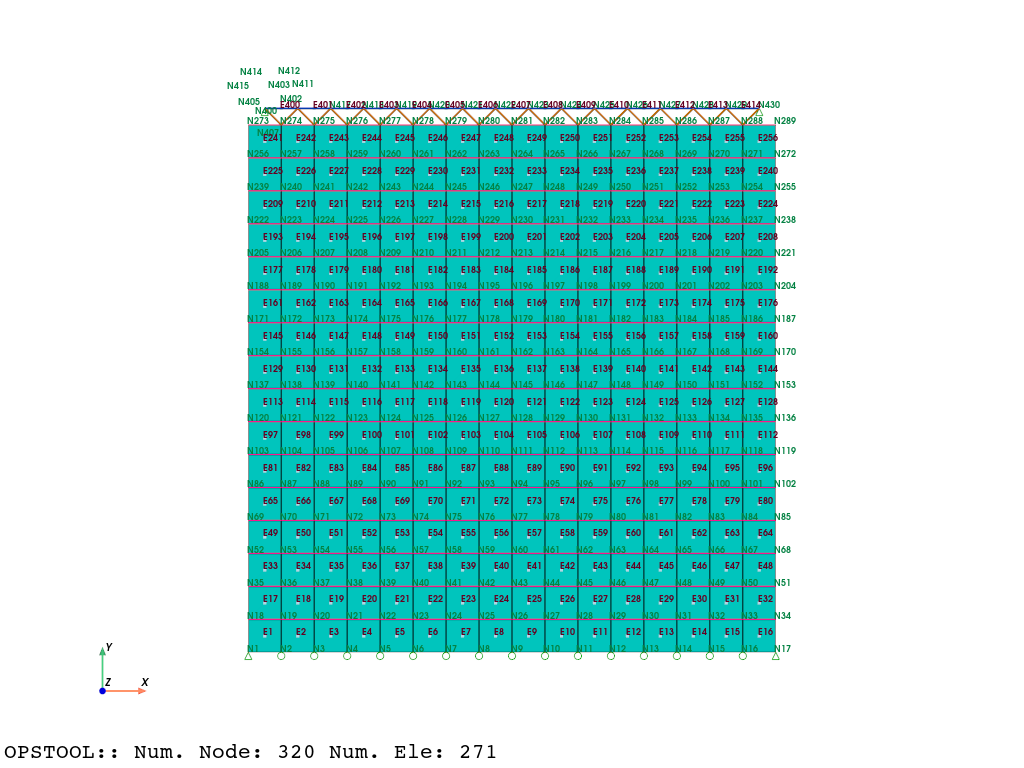

In [5]:
from functions.pad_footing_analysis import found_fem

found_fem()
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(
    jupyter_backend="jupyterlab"
)

Create output database (ODB) file. Since some elements and nodes will be removed in subsequent analyses, ensure that model_update=True.

In [6]:
opst.vis.plotly.plot_model(show_node_numbering=True)

In [7]:
ODB = opst.post.CreateODB(odb_tag=1, model_update=True)

GRAVITY ANALYSIS (w/ INITIAL STATE ANALYSIS TO RESET DISPLACEMENTS)

In [8]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

Perform an initial state analysis, where elements with tags 1001–1042 are BeamContact2D.

In [9]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
ops.setParameter("-val", 0, "-eleRange", 3050, 3064, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


Update soil material to consider elastoplastic behavior and analyze a few more steps:

In [10]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
ops.setParameter("-val", 0, "-eleRange", 3050, 3064, "friction")

InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


REMOVE ELEMENTS TO SIMULATE EXCAVATION

In [ ]:
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 10)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

We first define a function to avoid repetitive removal of elements and nodes, and then proceed with several steps of analysis.

In [ ]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

: 

Remove objects associated with lift 1:

In [ ]:
# remove objects associated with lift 1
# soil elements
ele_tags = [241 ]
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

We can save all previous responses to a file:

In [ ]:
ODB.save_response()

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

Post-processing

In [ ]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

Since the result data has already been saved, we can read it at any time for post-processing:

In [ ]:
opsvis.set_plot_props(
    point_size=0, line_width=5, cmap="turbo", title_font_size=12, notebook=True
)

nodal responses

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

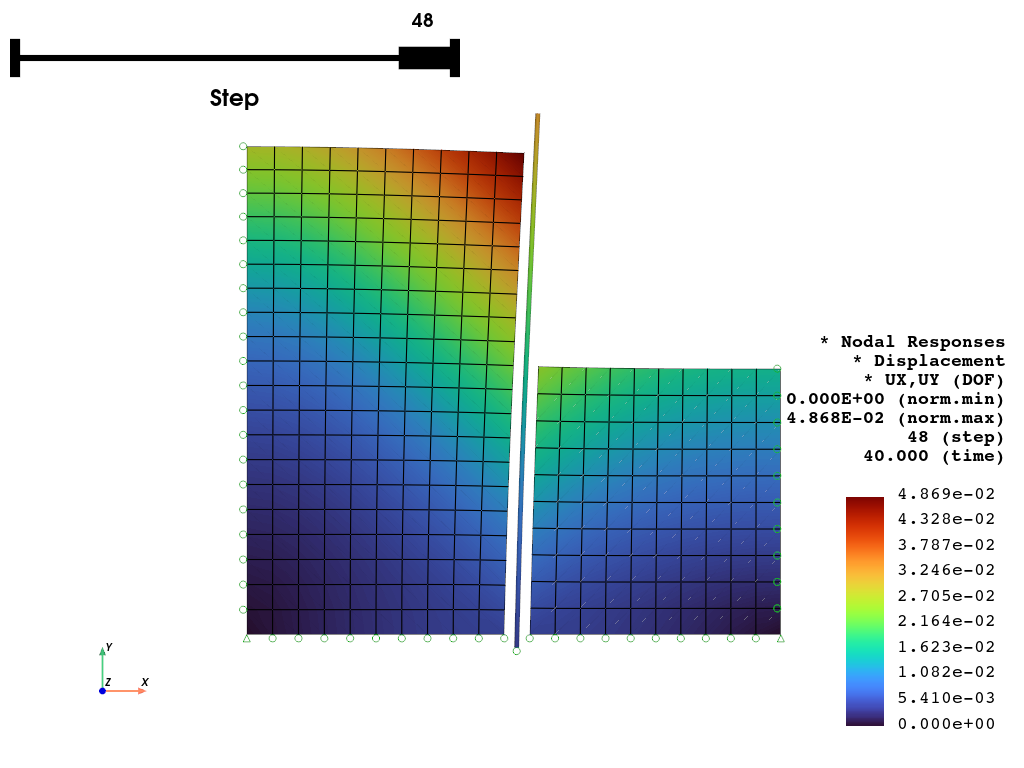

In [ ]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
).show(jupyter_backend="juoyterlab")

We can create animations:

In [ ]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=20,
    scale=2,
    savefig="NodalRespAnimation.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to NodalRespAnimation.gif!


![NodalRespAnimation.gif](NodalRespAnimation.gif)

Frame elements responses

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

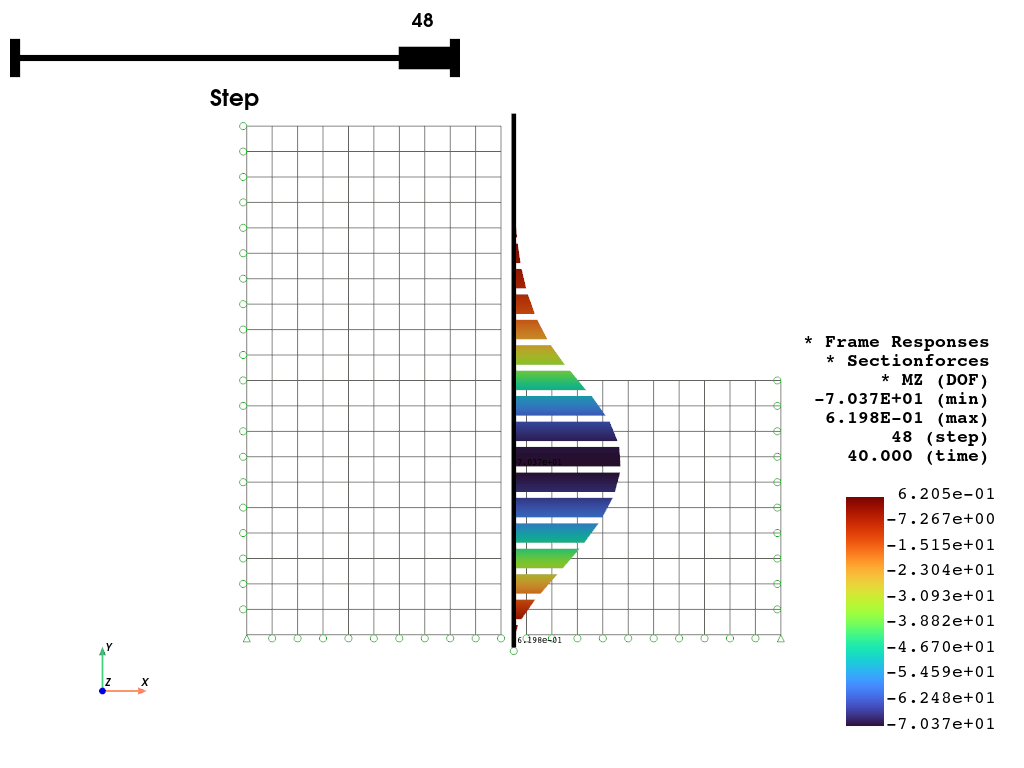

In [ ]:
opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    scale=3,
    slides=True,
    line_width=4,
).show(jupyter_backend="juoyterlab")

In [ ]:
opsvis.plot_frame_responses_animation(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    framerate=20,
    scale=3,
    line_width=4,
    savefig="FrameForcesMZ.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved as FrameForcesMZ.gif!


![FrameForcesMZ.gif](FrameForcesMZ.gif)

Plane elements response

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

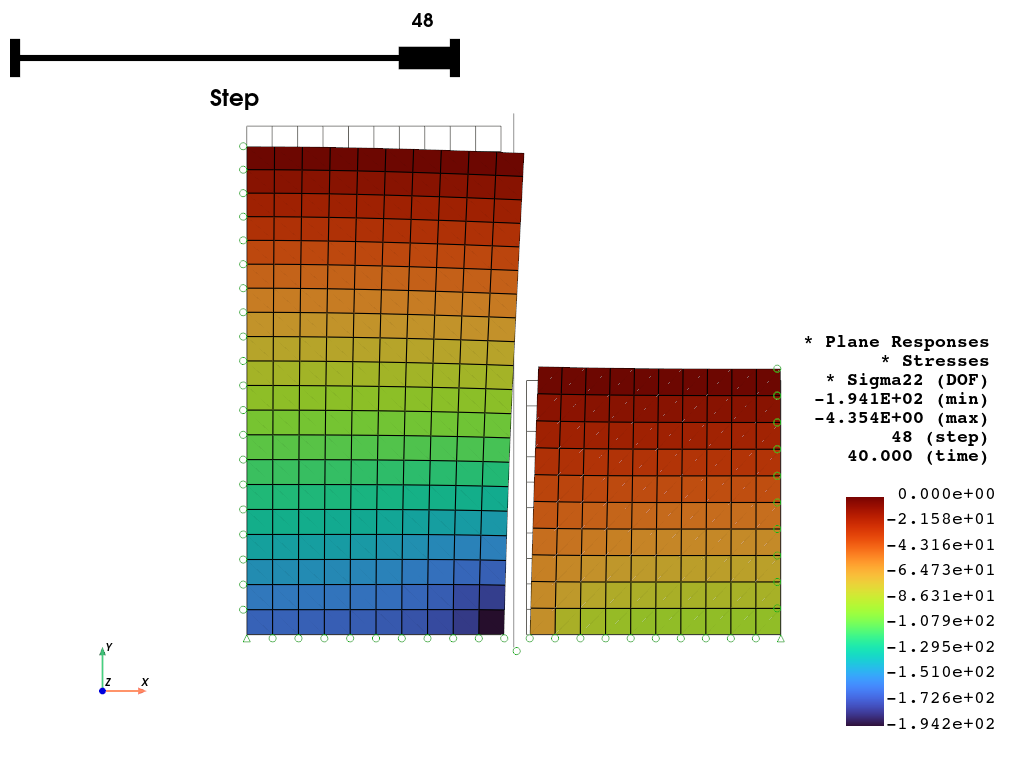

In [ ]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22"
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

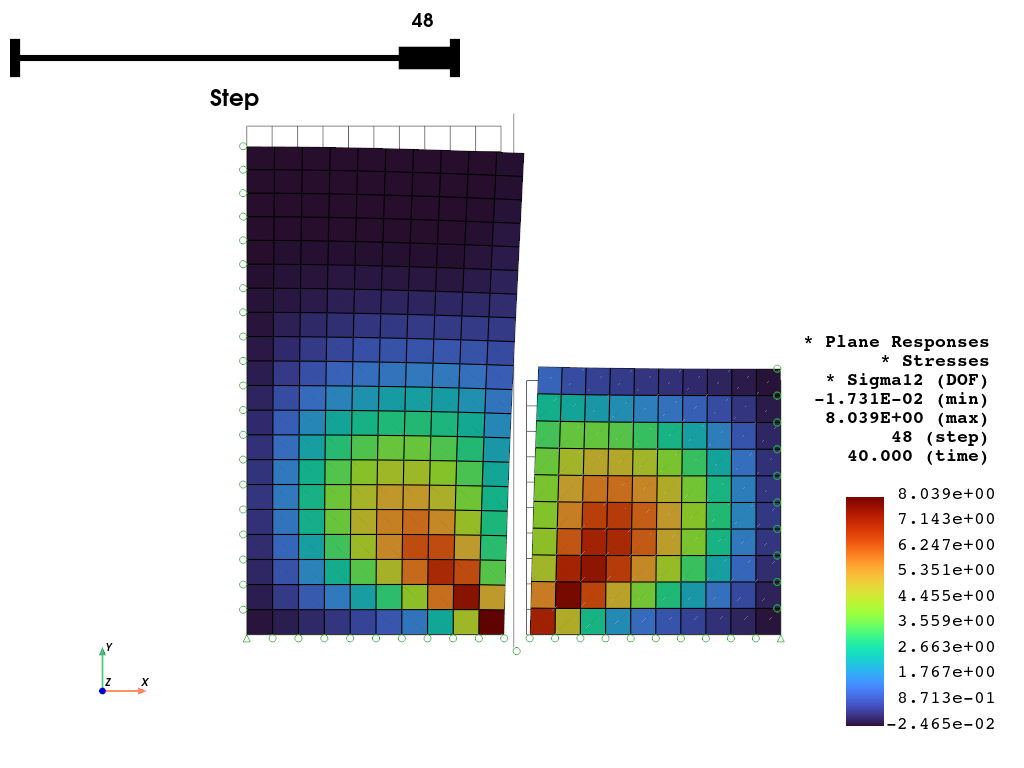

In [ ]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma12"
).show(jupyter_backend="jupyterlab")

Read data from ODB
Reading the response of the contact element

In [ ]:
data = opst.post.get_element_responses(odb_tag=1, ele_type="Contact")

OPSTOOL ::  Loading Contact response data from .opstool.output/RespStepData-1.nc ...

In [ ]:
print(data)

<xarray.Dataset> Size: 91kB
Dimensions:       (time: 49, eleTags: 42, globalDOFs: 3, localDOFs: 3,
                   slipDOFs: 2)
Coordinates:
  * eleTags       (eleTags) int64 336B 1001 1002 1003 1004 ... 1040 1041 1042
  * globalDOFs    (globalDOFs) <U2 24B 'Px' 'Py' 'Pz'
  * localDOFs     (localDOFs) <U2 24B 'N' 'Tx' 'Ty'
  * slipDOFs      (slipDOFs) <U2 16B 'Tx' 'Ty'
  * time          (time) float64 392B 0.0 1.0 2.0 3.0 ... 37.0 38.0 39.0 40.0
Data variables:
    globalForces  (time, eleTags, globalDOFs) float32 25kB -0.0 -0.0 ... nan nan
    localForces   (time, eleTags, localDOFs) float32 25kB 0.0 0.0 ... nan nan
    localDisp     (time, eleTags, localDOFs) float32 25kB 0.0 0.0 ... nan nan
    slips         (time, eleTags, slipDOFs) float32 16kB 0.0 0.0 0.0 ... nan nan
Attributes:
    Px:       Global force in the x-direction on the constrained node
    Py:       Global force in the y-direction on the constrained node
    Pz:       Global force in the z-direction on the constrai

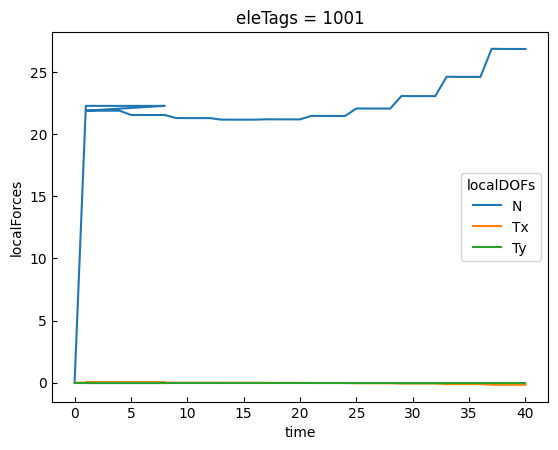

In [ ]:
data["localForces"].sel(eleTags=1001).plot.line(x="time")
plt.show()

Let’s examine the response of contact element #1034. Since it is removed during the fifth lift, its response is truncated at time=16, and subsequent data will be filled with numpy.nan.

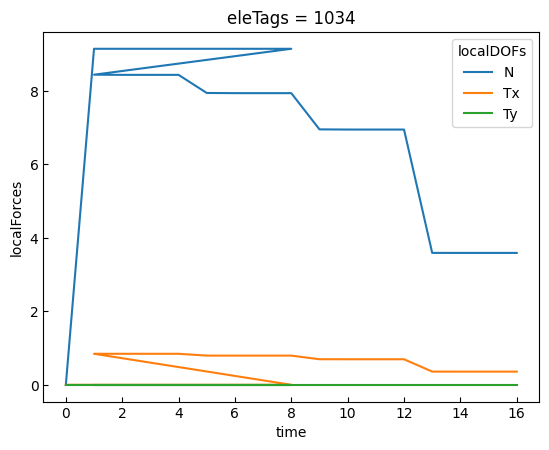

In [ ]:
data["localForces"].sel(eleTags=1034).plot.line(x="time")
plt.show()

In [ ]:
data["localForces"].sel(eleTags=1034).data

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 9.1395674e+00,  0.0000000e+00,  0.0000000e+00],
       [ 9.1395674e+00, -5.0713975e-16,  0.0000000e+00],
       [ 9.1395674e+00, -1.0979912e-15,  0.0000000e+00],
       [ 9.1395674e+00, -1.6520013e-15,  0.0000000e+00],
       [ 9.1395674e+00, -2.0548829e-15,  0.0000000e+00],
       [ 9.1395674e+00, -2.6420150e-15,  0.0000000e+00],
       [ 9.1395674e+00, -3.3185377e-15,  0.0000000e+00],
       [ 9.1395674e+00, -4.0539480e-15,  0.0000000e+00],
       [ 8.4345789e+00,  8.4345788e-01,  0.0000000e+00],
       [ 8.4302473e+00,  8.4302467e-01,  0.0000000e+00],
       [ 8.4302483e+00,  8.4302485e-01,  0.0000000e+00],
       [ 8.4302483e+00,  8.4302479e-01,  0.0000000e+00],
       [ 7.9376950e+00,  7.9376954e-01,  0.0000000e+00],
       [ 7.9328184e+00,  7.9328185e-01,  0.0000000e+00],
       [ 7.9328208e+00,  7.9328209e-01,  0.0000000e+00],
       [ 7.9328208e+00,  7.9328209e-01,  0.0000000e+00],
       [ 6.9473648e+00,  6.9473